## Import

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
%pip install optuna
%pip install wordcloud


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install nltk


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [4]:
import sys
sys.path.append('..')

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import nltk
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import paired_cosine_distances
import wordcloud
from wordcloud import WordCloud, STOPWORDS
from src.features import add_all_features, preprocess_text
from src.utils import plot_class_split_hist, find_mismatched_cases
from src.evaluation import compute_metrics, append_to_experiment_table, plot_confusion_matrix
from src.evaluation import train_and_evaluate, quick_log_loss
from sklearn.metrics import f1_score, roc_auc_score, log_loss, confusion_matrix
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
import optuna


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/nadiiababanska/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/nadiiababanska/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## Data loading

In [6]:
raw_df = pd.read_csv('/Users/nadiiababanska/Desktop/claude_coowork/ML_final_project/quora_question_pairs_train_.csv', index_col = 0)

In [7]:
raw_df

,qid1,qid2,question1,question2,is_duplicate
id,,,,,
332278,459256,459257,The Iliad and the Odyssey in the Greek culture?,How do I prove that the pairs of three indepen...,0
196656,297402,297403,What is practical management and what is strat...,What are the practical aspects of strategic ma...,0
113125,184949,184950,How useful is MakeUseOf Answers?,Is there any Q&A site that is not Yahoo answer...,0
266232,101283,163744,Which is the best place to reside in India and...,Which ia the best place to visit in India?,0
122738,17811,27517,Why do so many people ask questions on Quora t...,Why don't many people posting questions on Quo...,1
...,...,...,...,...,...
111701,182893,182894,What are the major stereotypes people have abo...,What are the major stereotypes people have abo...,0
90934,152504,152505,What are some of the best and most creative pr...,Which is one of the worst and most insensible ...,0
363857,493887,493888,Why is there a road named Aurangzeb in Delhi?,How do you justify naming a road after Aurangzeb?,0


## EDA

In [8]:
raw_df.describe()

,qid1,qid2,is_duplicate
count,323432.000000,323432.000000,323432.000000
mean,217326.769030,221048.081142,0.369197
std,157709.127417,159882.933077,0.482588
min,1.000000,2.000000,0.000000
25%,74614.750000,74859.500000,0.000000
50%,192394.500000,197271.500000,0.000000
75%,346599.250000,354727.000000,1.000000
max,537932.000000,537933.000000,1.000000


In [9]:
raw_df.info()

<class 'pandas.DataFrame'>
Index: 323432 entries, 332278 to 402019
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   qid1          323432 non-null  int64
 1   qid2          323432 non-null  int64
 2   question1     323431 non-null  str  
 3   question2     323430 non-null  str  
 4   is_duplicate  323432 non-null  int64
dtypes: int64(3), str(2)
memory usage: 51.8 MB


In [10]:
#searching for rows with null values
print(raw_df.isnull().sum())

qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64


In [11]:
# indices of rows with null values
null_idx = raw_df.isnull().any(axis=1)
print(raw_df[null_idx])

          qid1    qid2                         question1  \
id                                                         
363362  493340  493341                               NaN   
201841  303951  174364  How can I create an Android app?   
105780  174363  174364    How can I develop android app?   

                                                question2  is_duplicate  
id                                                                       
363362  My Chinese name is Haichao Yu. What English na...             0  
201841                                                NaN             0  
105780                                                NaN             0  


In [12]:
#deleting the row with null values ​​and overwrite the dataframe
raw_df = raw_df.dropna(subset=['question1', 'question2']).copy()

### Conclusion:
Out of 323432 rows, only 3 had missing values. Removing them would not affect the solution of the problem, so I removed them

In [13]:
#Checking class imbalance
raw_df.is_duplicate.value_counts(normalize=True)

is_duplicate
0    0.6308
1    0.3692
Name: proportion, dtype: float64

([<matplotlib.axis.XTick at 0x15418de80>,
 [Text(0, 0, 'Not duplicate'), Text(1, 0, 'Duplicate')])

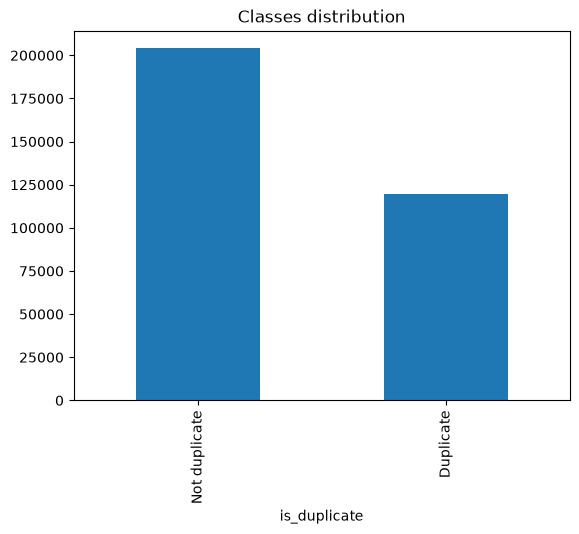

In [14]:
raw_df.is_duplicate.value_counts().plot(kind='bar')
plt.title('Classes distribution')
plt.xticks([0,1], ['Not duplicate', 'Duplicate'])

## Feature generation & more EDA

In [15]:

add_all_features(raw_df, q1_col="question1", q2_col="question2")


,qid1,qid2,question1,question2,is_duplicate,question1_len,question2_len,len_dif,common_words,jaccard_similarity,word_match_share,bigrams_common,bigram_jaccard_similarity,bigram_word_match_share,cosine_similarity
id,,,,,,,,,,,,,,,
332278,459256,459257,The Iliad and the Odyssey in the Greek culture?,How do I prove that the pairs of three indepen...,0,47,81,-34,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000
196656,297402,297403,What is practical management and what is strat...,What are the practical aspects of strategic ma...,0,62,55,7,3.0,0.750000,0.428571,1.0,0.200000,0.166667,0.813429
113125,184949,184950,How useful is MakeUseOf Answers?,Is there any Q&A site that is not Yahoo answer...,0,32,78,-46,1.0,0.111111,0.100000,0.0,0.000000,0.000000,0.127280
266232,101283,163744,Which is the best place to reside in India and...,Which ia the best place to visit in India?,0,51,42,9,3.0,0.500000,0.333333,1.0,0.166667,0.142857,0.448950
122738,17811,27517,Why do so many people ask questions on Quora t...,Why don't many people posting questions on Quo...,1,159,68,91,4.0,0.266667,0.210526,1.0,0.062500,0.058824,0.302705
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
111701,182893,182894,What are the major stereotypes people have abo...,What are the major stereotypes people have abo...,0,90,89,1,5.0,0.714286,0.416667,3.0,0.428571,0.300000,0.725539
90934,152504,152505,What are some of the best and most creative pr...,Which is one of the worst and most insensible ...,0,84,86,-2,2.0,0.250000,0.200000,1.0,0.142857,0.125000,0.358950
363857,493887,493888,Why is there a road named Aurangzeb in Delhi?,How do you justify naming a road after Aurangzeb?,0,45,49,-4,3.0,0.600000,0.375000,0.0,0.000000,0.000000,0.811099


In [16]:
raw_df.to_csv('/Users/nadiiababanska/Desktop/claude_coowork/ML_final_project/quora_with_features.csv', index=True)

In [17]:
print(raw_df['question1_len'].describe())

count    323429.000000
mean         59.531761
std          29.921286
min           1.000000
25%          39.000000
50%          52.000000
75%          72.000000
max         623.000000
Name: question1_len, dtype: float64


In [18]:
print(raw_df['question2_len'].describe())

count    323429.000000
mean         60.123242
std          33.889595
min           1.000000
25%          39.000000
50%          51.000000
75%          72.000000
max        1169.000000
Name: question2_len, dtype: float64


In [19]:
#deviding full test set on 2 subsets: duplicates and not_duplicates

duplicates = raw_df[raw_df['is_duplicate'] == 1]
not_duplicates = raw_df[raw_df['is_duplicate'] == 0]

#### Analysis of statistical moments of duplicates and not_duplicates

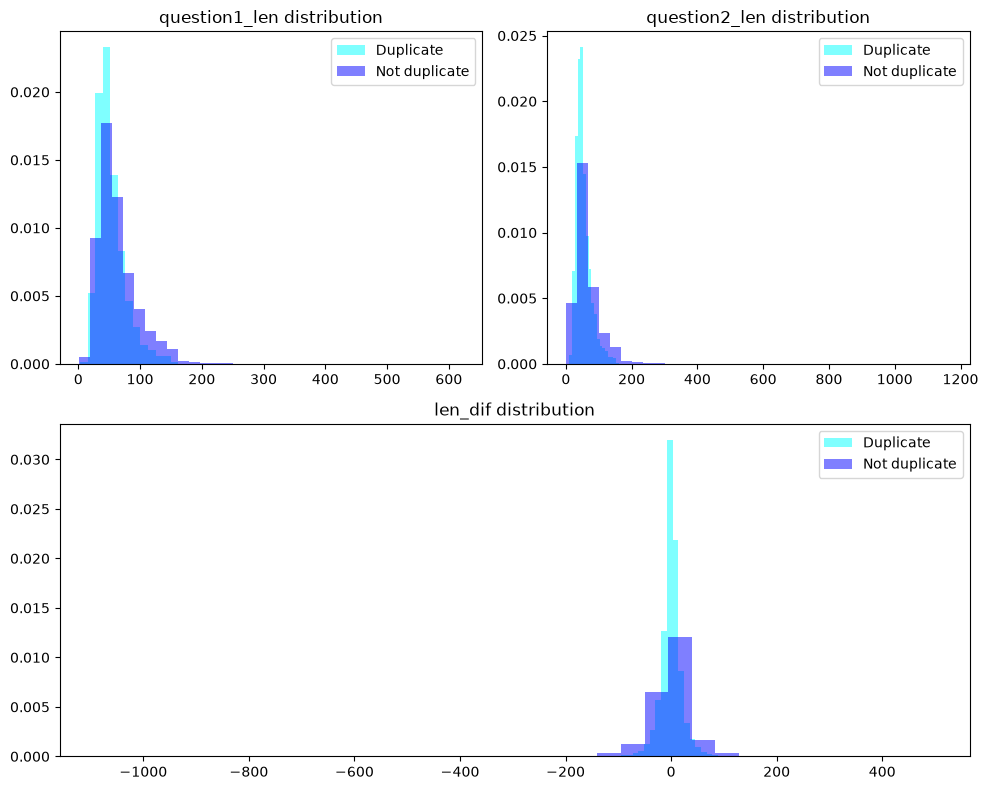

In [20]:
plt.figure(figsize=(10,8))

plt.subplot(2, 2, 1)
plot_class_split_hist(duplicates, not_duplicates, 'question1_len')

plt.subplot(2, 2, 2)
plot_class_split_hist(duplicates, not_duplicates, 'question2_len')

plt.subplot(2, 1, 2)
plot_class_split_hist(duplicates, not_duplicates, 'len_dif')

plt.tight_layout()
plt.show()

In [21]:
print(f'Q1 length variance in duplicates: {duplicates['question1_len'].var()}')
print(f'Q1 length variance in not_duplicates: {not_duplicates['question1_len'].var()}')

Q1 length variance in duplicates: 544.3865850328837
Q1 length variance in not_duplicates: 1058.9736062179281


In [22]:
print(f'Q2 length variance in duplicates: {duplicates['question2_len'].var()}')
print(f'Q2 length variance in not_duplicates: {not_duplicates['question2_len'].var()}')

Q2 length variance in duplicates: 540.8729156994409
Q2 length variance in not_duplicates: 1455.9419173519248


In [23]:
print(f'Q1 length kurtosis in duplicates: {duplicates['question1_len'].kurtosis()}')
print(f'Q1 length kurtosis in not_duplicates: {not_duplicates['question1_len'].kurtosis()}')

Q1 length kurtosis in duplicates: 4.171344166726708
Q1 length kurtosis in not_duplicates: 4.6548898572360144


In [24]:
print(f'Q2 length kurtosis in duplicates: {duplicates['question2_len'].kurtosis()}')
print(f'Q2 length kurtosis in not_duplicates: {not_duplicates['question2_len'].kurtosis()}')

Q2 length kurtosis in duplicates: 3.702451437092854
Q2 length kurtosis in not_duplicates: 50.62466344406163


In [25]:
print(f'Length difference Q1-Q2 variance in duplicates: {duplicates['len_dif'].var()}')
print(f'Length difference Q1-Q2 variance in not_duplicates: {not_duplicates['len_dif'].var()}')

Length difference Q1-Q2 variance in duplicates: 380.5788105790839
Length difference Q1-Q2 variance in not_duplicates: 1460.0427132430757


In [26]:
print(f'Length difference Q1-Q2 kurtosis in duplicates {duplicates['len_dif'].kurtosis()}')
print(f'Length difference Q1-Q2 kurtosis in not_duplicates: {not_duplicates['len_dif'].kurtosis()}')

Length difference Q1-Q2 kurtosis in duplicates 4.798909321034921
Length difference Q1-Q2 kurtosis in not_duplicates: 39.13918674415612


#### Unique words analysis

In [27]:
Q1_Q2_series = pd.concat([raw_df['question1'], raw_df['question2']], ignore_index=True)

In [28]:
Q1_Q2_series

0           The Iliad and the Odyssey in the Greek culture?
1         What is practical management and what is strat...
2                          How useful is MakeUseOf Answers?
3         Which is the best place to reside in India and...
4         Why do so many people ask questions on Quora t...
                                ...                        
646853    What are the major stereotypes people have abo...
646854    Which is one of the worst and most insensible ...
646855    How do you justify naming a road after Aurangzeb?
646856    Can a high school teacher legally force studen...
646857    Why isn't polylactic acid being used more, in ...
Length: 646858, dtype: str

In [29]:
#conversion to vectors
vectorizer = CountVectorizer(stop_words='english')

vect_questions = vectorizer.fit(Q1_Q2_series)

vect_q1 = vectorizer.transform(raw_df.question1)
vect_q2 = vectorizer.transform(raw_df.question2)

In [30]:
print(f"Total number of unique words: {len(vectorizer.vocabulary_)}")

Total number of unique words: 77733


In [31]:
total_matrix = vect_q1 + vect_q2
word_freq = total_matrix.sum(axis=0).A1
most_freq_words = pd.Series(word_freq, index=vectorizer.get_feature_names_out())


Text(0.5, 1.0, 'The least used words')

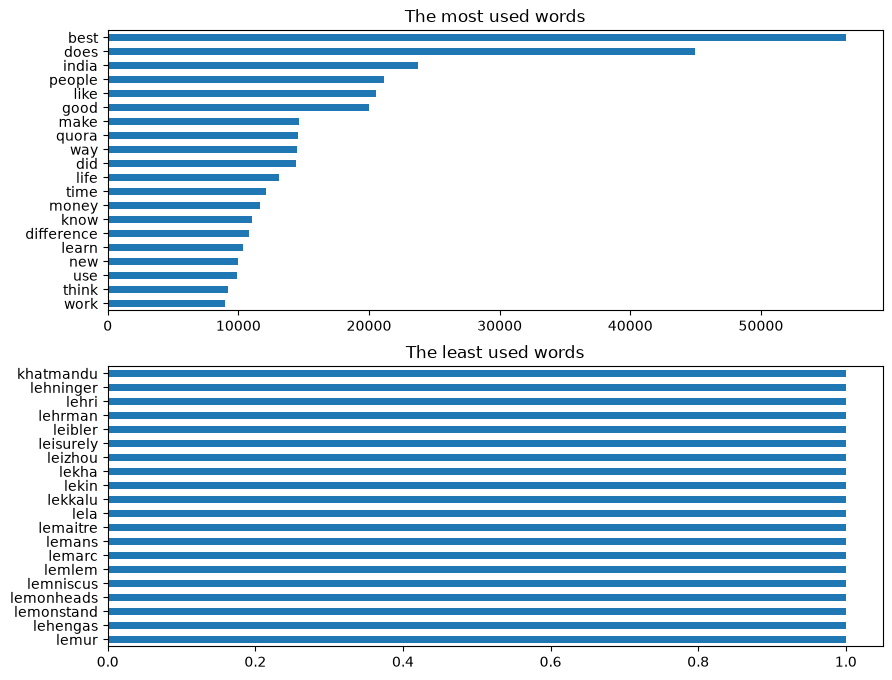

In [32]:
plt.figure(figsize=(10,8))
plt.subplot(2, 1, 1)
most_freq_words.sort_values(ascending=False).head(20).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('The most used words')


plt.subplot(2, 1, 2)
most_freq_words.sort_values(ascending=True).head(20).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title('The least used words')

Observation:
- classes are unbalanced
- question length distributions are right-skewed
- duplicate class length distribution has lower variance and higher kurtosis
- entire question set has 77733 (without stop_words='english') unique words
- least frequently used words are sets of numbers and symbols (non-Latin)

## Q1 vs Q2 comparison

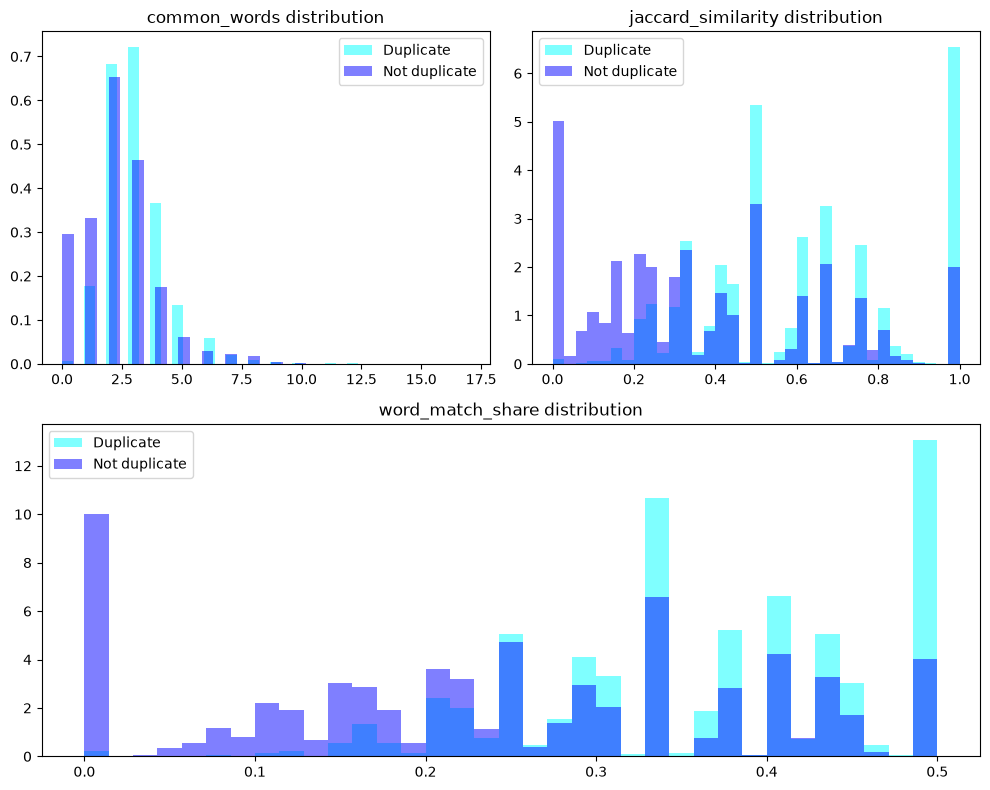

In [33]:
#Defining the number of common words and part of common words relatively to all words in Q1 and Q2
plt.figure(figsize=(10,8))

plt.subplot(2, 2, 1)
plot_class_split_hist(duplicates, not_duplicates, 'common_words')

plt.subplot(2, 2, 2)
plot_class_split_hist(duplicates, not_duplicates, 'jaccard_similarity')

plt.subplot(2, 1, 2)
plot_class_split_hist(duplicates, not_duplicates, 'word_match_share')

plt.tight_layout()
plt.show()

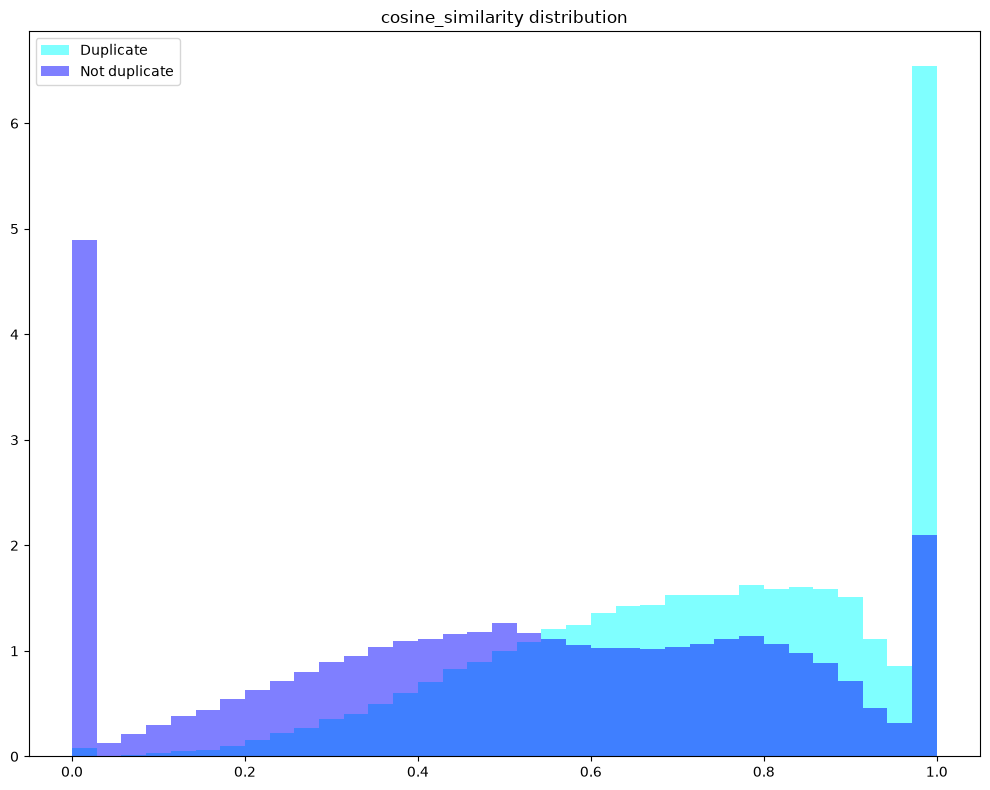

In [34]:
#cosine similarity

plt.figure(figsize=(10,8))

plot_class_split_hist(duplicates, not_duplicates, 'cosine_similarity')

plt.tight_layout()
plt.show()

Observation:
jaccard_similarity, word_match_share have different distributions for duplicate/not duplicate classes, so they can be informative features for the model. For the common_words distribution, the difference is not so noticeable, but I will leave this feature as well.
cosine_similarity - has the largest difference in distributions for duplicates and non-duplicates.

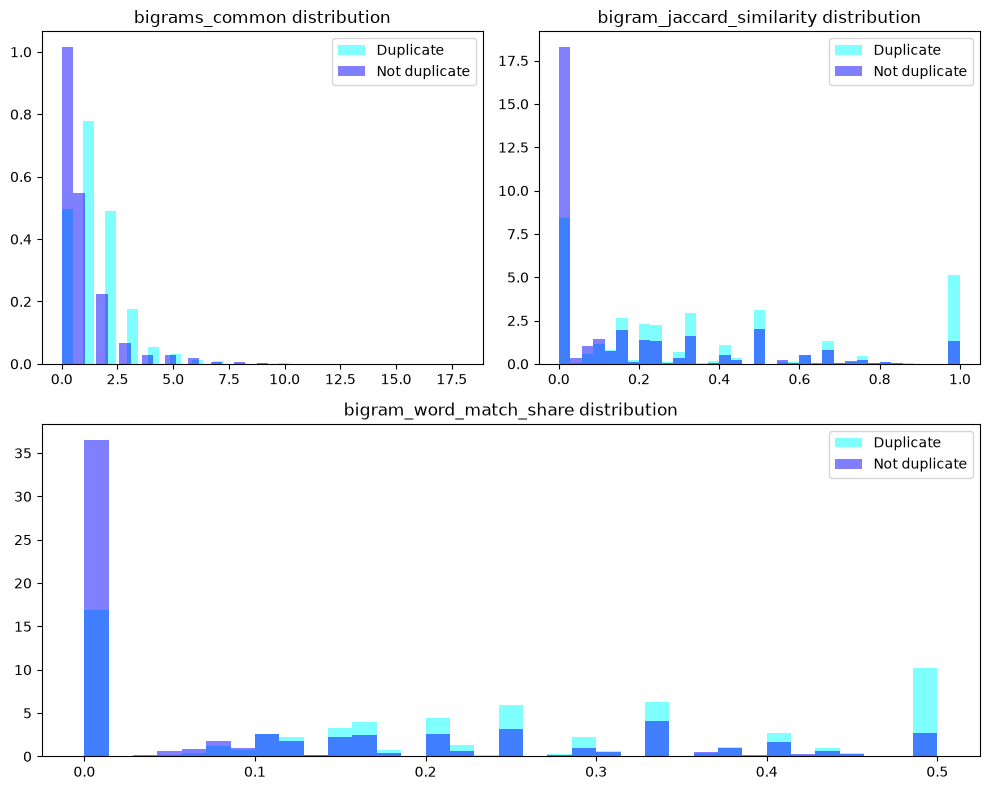

In [35]:
#bigram conparison

plt.figure(figsize=(10,8))

plt.subplot(2, 2, 1)
plot_class_split_hist(duplicates, not_duplicates, 'bigrams_common')

plt.subplot(2, 2, 2)
plot_class_split_hist(duplicates, not_duplicates, 'bigram_jaccard_similarity')

plt.subplot(2, 1, 2)
plot_class_split_hist(duplicates, not_duplicates, 'bigram_word_match_share')

plt.tight_layout()
plt.show()

Observation: bigrams turned out to be a not very informative feature because they are not sensitive to paraphrasing and are sensitive to word order, so in most cases questions do not have common bigrams.

In [36]:
#building a wordcloud for duplicates and non-duplicates

cloud_duplicates = ''.join(duplicates['question1'].tolist() + duplicates['question2'].tolist())
cloud_not_duplicates = ''.join(not_duplicates['question1'].tolist() + not_duplicates['question2'].tolist())

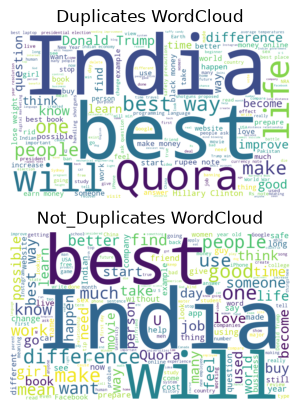

In [37]:
wc_duplicates = WordCloud(
    width =1000,
    height = 600,
    background_color = 'white',
    stopwords = STOPWORDS
    ).generate(cloud_duplicates)

wc_not_duplicates = WordCloud(
    width = 1000,
    height = 600,
    background_color = 'white',
    stopwords = STOPWORDS
    ).generate(cloud_not_duplicates)

plt.subplot(2,1,1)
plt.imshow(wc_duplicates, interpolation='bilinear')
plt.title('Duplicates WordCloud')
plt.axis('off')

print('\n')

plt.subplot(2,1,2)
plt.imshow(wc_not_duplicates, interpolation='bilinear')
plt.title('Not_Duplicates WordCloud')
plt.axis('off')

plt.show()

Observation:
WordCloud showed that both categories have a similar set of words. That is, the general search topic coincides for all questions, the difference should be sought in the pairs of questions.

## Search for cases where similarity does not match the label

In [38]:
false_similar_jac = find_mismatched_cases(raw_df, 'jaccard_similarity', 0.5, direction='above', target_label=0)

false_similar_cos = find_mismatched_cases(raw_df, 'cosine_similarity', 0.6, direction='above', target_label=0)

false_unsimilar_jac = find_mismatched_cases(raw_df, 'jaccard_similarity', 0.1, direction='below', target_label=1)

false_unsimilar_cos = find_mismatched_cases(raw_df, 'cosine_similarity', 0.2, direction='below', target_label=1)



In [39]:
false_similar_jac[['question1', 'question2', 'jaccard_similarity']]

,question1,question2,jaccard_similarity
id,,,
196656,What is practical management and what is strat...,What are the practical aspects of strategic ma...,0.750000
302372,Why do people avoid south facing homes?,"Why is a ""south facing"" home so important to s...",0.666667
239687,When did you join Quora?,Why did I join Quora?,1.000000
366190,What are the disadvantages of hiring foreign w...,What are the advantages of hiring foreign work...,0.600000
119588,What universities does Spectrum Brands recruit...,What universities does Boulder Brands recruit ...,0.800000
...,...,...,...
9428,How can I find a job in China?,How can one find a job outside of China?,0.666667
233101,What is the solution to this puzzle?,What is the solution to these puzzles?,1.000000
212748,Do employees at Safe Bulkers have a good work-...,Do employees at Scorpio Bulkers have a good wo...,0.800000


In [40]:
false_similar_cos[['question1', 'question2', 'cosine_similarity']]

,question1,question2,cosine_similarity
id,,,
196656,What is practical management and what is strat...,What are the practical aspects of strategic ma...,0.813429
302372,Why do people avoid south facing homes?,"Why is a ""south facing"" home so important to s...",0.790131
241523,Can XY chromosomes change to XX ones?,What are XX and XY chromosomes? How are they d...,0.883263
239687,When did you join Quora?,Why did I join Quora?,1.000000
298798,How do I download free movies from torrent?,How do I download from torrent?,0.785386
...,...,...,...
337907,Can a Guitar Hero guitar be used in Rock Band?,Can Guitar Hero be useful to me later on in li...,0.641794
212748,Do employees at Safe Bulkers have a good work-...,Do employees at Scorpio Bulkers have a good wo...,0.859825
15401,How do I move past my fear and learn options?,How do you move past fear?,0.790345


In [41]:
false_unsimilar_jac[['question1', 'question2', 'jaccard_similarity']].head(20)

,question1,question2,jaccard_similarity
id,,,
82526,"If you were an animal, which one would you be?","If you were reincarnated as an animal/bird, wh...",0.000000
7604,What do you think about the Modi's sudden deci...,What's your opinion on Indian Prime Minister M...,0.062500
250786,Is there anyway to come out of bro-zone?,How do I get out of the bro-zone?,0.000000
266247,Why are Quorans so left-wing?,Why is Quora so left-wing?,0.000000
200431,How do i get myself a girlfriend?,How do I get a girl's attention?,0.000000
130039,How is banning 500 and 1000 INR going to help ...,What is the use of banning 500 and 1000 rupee ...,0.090909
399437,How do i get myself a girlfriend?,How do you get a girl to like you?,0.000000
52116,Do you think scrapping of 500 and 1000 rupee d...,How can discontinuing 500 and 1000 rupee will ...,0.083333
339101,What is something you never do?,What is something you have never done?,0.000000


In [42]:
false_unsimilar_cos[['question1', 'question2', 'cosine_similarity']].head(20)

,question1,question2,cosine_similarity
id,,,
64894,Is the human life more important than the life...,Do human lives have any more value than other ...,0.141036
82526,"If you were an animal, which one would you be?","If you were reincarnated as an animal/bird, wh...",0.000000
164040,How do I lose weight ayurvedically?,How can I loose weight for wedding?,0.192997
402733,Where can I buy T-shirts online in India?,What is the best e-commerce site to order T-sh...,0.192994
236667,What are the effects of demonetization in India?,Is demonetisation good for India?,0.172913
7604,What do you think about the Modi's sudden deci...,What's your opinion on Indian Prime Minister M...,0.107819
112786,How can I speaking fluently speaking English?,How can I continue to improve my English?,0.167212
226339,How do I get rid of acne and acne causes?,How do I get rid of pimples permanently?,0.178738
153225,How does life come from non-life?,How did life originate from non-living? An ord...,0.177178


Observations
- cases where there is no duplicate tag, but there is a high jaccard_similarity or cosine_similarity - this is a sentence with 1 or a pair of words that are different, and this changes the context or meaning of the sentence

- cases where there is a duplicate tag, but a low jaccard_similarity or cosine_similarity, the sentences use synonymous expressions that mean the same thing, or different parts of speech with a common root, or metaphors

In [43]:
preprocess_text("What questions are running late?")

'question run late'